#### 사전수행(Anaconda Prompt)
- pip install scikit-learn
- pip install matplotlib

### 혼동행렬 (Confusion Matrix)

- 주로 알고리즘이나 모델의 성능을 평가할 때 많이 사용됨

| **실제** \ 예측 | Positive | Negative |
|---|---:|---:|
| **Positive** | TP | FN |
| **Negative** | FP | TN |
- **TP (True Positive)**: 실제 양성을 양성으로 예측
- **FN (False Negative)**: 실제 양성을 음성으로 예측
- **FP (False Positive)**: 실제 음성을 양성으로 예측
- **TN (True Negative)**: 실제 음성을 음성으로 예측

### 정확도 (Accuracy)

- 자주 사용되고, 가장 기본이 되는 지표
$$
\mathrm{ACC} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- 데이터가 불균형할 때 적절하지 못한 지표로써 잘못 사용될 가능성이 있음.

### F1-스코어
- 정밀도와 재현율의 임계치를 잘못 설정하면 극단적인 경우가 발생할 수 있음

  => 이를 방지하기 위하여 [**F1-스코어**]를 사용한다.

$$
F_1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$

- F1-스코어는 재현율과 정밀도의 중요성이 같다고 가정하고, 두 지표의 조화평균으로 만들어진 지표
- 해당 지표의 수치가 높다고 해서 꼭 올바른 것은 아님


In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 0 : 햄버거
# 1 : 유통기한이 지난 햄버거
y_true = [0, 1, 1, 1, 1, 0, 1, 1, 0, 0]

# 클래스에 대한 확률은 임의로 지정
A_proba = [0.6, 0.7, 0.7, 0.8, 0.9, 0.7, 0.85, 0.7, 0.65, 0.75]
B_proba = [0.05, 0.05, 0.1, 0.3, 0.6, 0.3, 0.4, 0.5, 0.2, 0.1]
# 완벽한 모델
C_proba = [0, 1, 1, 1, 1, 0, 1, 1, 0, 0]

In [4]:
# ROC 곡선을 그리기 위한 값과 AUC 값을 변수에 저장
fpr_A, tpr_A, thr_A = roc_curve(y_true, A_proba)
fpr_B, tpr_B, thr_B = roc_curve(y_true, B_proba)
fpr_C, tpr_C, thr_C = roc_curve(y_true, C_proba)

auc_A = auc(fpr_A, tpr_A)
auc_B = auc(fpr_B, tpr_B)
auc_C = auc(fpr_C, tpr_C)

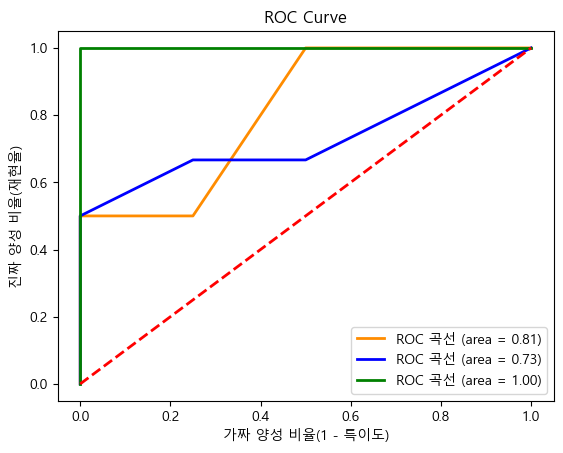

In [5]:
plt.xlabel('가짜 양성 비율(1 - 특이도)')
plt.ylabel('진짜 양성 비율(재현율)')
plt.title('ROC Curve')

plt.plot(fpr_A, tpr_A, color='darkorange',
        lw=2, label=f'ROC 곡선 (area = {auc_A:.2f})')
plt.plot(fpr_B, tpr_B, color='blue',
        lw=2, label=f'ROC 곡선 (area = {auc_B:.2f})')
plt.plot(fpr_C, tpr_C, color='green',
        lw=2, label=f'ROC 곡선 (area = {auc_C:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc='lower right')
plt.show()

**1**번 모델 : 가장 완벽한 모델이기에 차치

**2**번 모델과 **3**번 모델 중에 골라야하는 상황

- 일반적으로 AUC를 기준으로 본다면 **3**번 모델
- 반면, 높은 재현율과 0.3 이하의 가짜 양성 비율을 기준으로 잡는다면 **2**번 모델